# Modello di classificazione dei pezzi difettosi in produzione
## AutomaParts S.p.A. - Linea di assemblaggio bracci trasversali

---

# Relazione tecnica

## 1. Analisi preliminare

### Contesto aziendale

AutomaParts S.p.A. è un fornitore tier-1 del settore automotive che produce componenti meccanici di precisione per sistemi sterzo e sospensioni. La qualità dei pezzi è un requisito critico: un pezzo difettoso che raggiunge l'assemblaggio finale può causare fermi macchina, costi di rilavorazione elevati o richiami da parte degli OEM, con impatti economici e reputazionali significativi.

### Il problema di classificazione

Per ogni pezzo prodotto vengono registrate misure dimensionali (diametro, lunghezza, planaritá), parametri di processo (temperatura, coppia, vibrazione, tempo ciclo), informazioni sulla rugosità superficiale e un punteggio da ispezione visiva. A fine ciclo viene assegnata l'etichetta binaria `defect_label` (0=conforme, 1=difettoso).

L'obiettivo è addestrare un modello di machine learning supervisionato che predica automaticamente la presenza di un difetto, basandosi sulle misure registrate in linea. Il risultato atteso è uno strumento a supporto delle decisioni operative: scarto automatico, controllo aggiuntivo o via libera in produzione.

### Sfide principali

- **Sbilanciamento delle classi**: i pezzi difettosi sono circa il 22% del dataset. La sola accuracy non è affidabile come metrica: un modello che predicesse sempre "conforme" raggiungerebbe il 78% di accuracy senza rilevare nessun difetto. Sono necessarie metriche come F1-score e ROC-AUC.
- **Costo asimmetrico degli errori**: un falso negativo (difettoso classificato come conforme) ha un costo operativo molto più alto di un falso positivo (conforme fermato per controllo aggiuntivo). La soglia di classificazione deve tenere conto di questo rapporto.
- **Dati eterogenei**: il dataset contiene variabili numeriche continue, identificativi categorici e un timestamp. Serve un pre-processing coerente prima dell'addestramento.
- **Interpretabilità**: gli ingegneri di processo devono capire quali variabili incidono sulla difettosità per poter intervenire sulle cause.

## 2. Scelte tecniche

### Modelli selezionati

Sono stati scelti tre algoritmi con caratteristiche complementari:

| Modello | Motivazione | Vantaggio | Limite |
|---|---|---|---|
| Decision Tree | baseline interpretabile | regole leggibili dagli operatori | tende all'overfitting su dati rumorosi |
| Random Forest | ensemble robusto | riduce la varianza del singolo albero | meno interpretabile |
| Logistic Regression | baseline lineare probabilistica | output probabilistico calibrato | assume separabilità lineare tra le classi |

### Gestione dei dati mancanti

- variabili numeriche: imputazione con la mediana, scelta per la robustezza agli outlier
- variabili categoriche: imputazione con la moda

### Feature engineering

- `production_timestamp` viene scomposto in `hour_of_day`, `day_of_week` e `month`, usati come proxy per il turno di lavoro, che può influenzare la qualità del processo
- dal codice `material_batch` viene estratta la settimana di produzione (`batch_week`) per catturare variazioni stagionali nella materia prima
- `line_id`, `station_id` e `operator_id` vengono trattati come variabili numeriche ordinali

### Scaling e valutazione

- StandardScaler sulle variabili numeriche (necessario in particolare per la regressione logistica)
- split stratificato 80/20 per preservare le proporzioni tra le classi in train e test
- cross-validation a 5 fold per verificare la stabilità delle stime di performance
- metriche principali: ROC-AUC, F1-score sulla classe difettosa e recall dei difettosi

---

# NOTEBOOK - Sviluppo del modello

## Sezione 0 - Import delle librerie

In [560]:
# Installa eventuali librerie mancanti (Google Colab)
# !pip install pandas numpy matplotlib seaborn scikit-learn -q

# Librerie standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn: pre-processing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Scikit-learn: modelli
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Scikit-learn: metriche
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

RANDOM_STATE = 0 # seed per riproducibilità

print('Librerie caricate correttamente.')

Librerie caricate correttamente.


## Sezione 1 - Caricamento del Dataset

In [561]:
# Percorso del file CSV relativo alla posizione del notebook
# DATA_PATH = 'datasets/parts_production_data.csv'

# Percorso del file CSV su web (caricare direttamente da URL)
DATA_PATH = 'https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20di%20classificazione%20di%20pezzi%20difettosi%20in%20produzione/parts_production_data.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset caricato: {df.shape[0]} righe x {df.shape[1]} colonne')
df.head()

Dataset caricato: 3000 righe x 16 colonne


,part_id,production_timestamp,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,material_batch,visual_inspection_score,defect_label
0,1,2024-06-13 17:42:45,2,1,5,15.582,34.100,34.813,318.147,33.620,72.543,0.093695,146.532,MB-2024W24-L02-575,0.602019,1
1,2,2024-07-26 10:36:48,9,14,4,42.377,30.260,36.116,379.256,23.610,82.438,0.957213,167.319,MB-2024W30-L09-100,0.092746,0
2,3,2025-12-08 17:35:40,6,20,5,25.141,52.082,36.588,347.408,44.468,116.188,0.704572,109.165,MB-2025W50-L06-297,0.227898,0
3,4,2024-12-09 12:56:36,4,4,7,35.427,44.593,27.404,183.803,20.679,144.932,0.648035,221.826,MB-2024W50-L04-747,0.171139,0
4,5,2025-09-08 15:54:15,8,13,5,22.618,40.710,24.220,477.164,45.055,95.174,0.655439,179.126,MB-2025W37-L08-470,0.914548,1


In [562]:
# Panoramica dei tipi di dati e valori non nulli
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   part_id                  3000 non-null   int64  
 1   production_timestamp     3000 non-null   object 
 2   line_id                  3000 non-null   int64  
 3   station_id               3000 non-null   int64  
 4   operator_id              3000 non-null   int64  
 5   measure_diam_mm          3000 non-null   float64
 6   measure_length_mm        3000 non-null   float64
 7   flatness_mm              3000 non-null   float64
 8   torque_Nm                3000 non-null   float64
 9   surface_roughness_Ra     3000 non-null   float64
 10  temp_process_C           3000 non-null   float64
 11  vibration_level          3000 non-null   float64
 12  cycle_time_s             3000 non-null   float64
 13  material_batch           3000 non-null   object 
 14  visual_inspection_score 

In [563]:
# Statistiche descrittive (scale, range, valori anomali)
df.describe().round(3)

,part_id,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,defect_label
count,3000.00,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,1500.50,5.548,10.632,5.497,30.261,49.708,29.824,302.045,29.888,110.732,0.496,200.483,0.498,0.224
std,866.17,2.825,5.808,2.869,11.407,11.536,5.798,115.859,11.639,23.245,0.286,57.752,0.286,0.417
min,1.00,1.000,1.000,1.000,10.014,30.005,20.003,100.085,10.000,70.006,0.000,100.094,0.000,0.000
25%,750.75,3.000,5.750,3.000,20.643,39.667,24.744,201.608,19.955,90.625,0.254,149.544,0.249,0.000
50%,1500.50,6.000,11.000,6.000,30.277,49.451,29.795,303.522,29.670,111.266,0.495,200.840,0.510,0.000
75%,2250.25,8.000,16.000,8.000,39.928,59.595,34.846,400.808,40.269,131.194,0.745,250.877,0.744,0.000
max,3000.00,10.000,20.000,10.000,49.997,69.986,39.994,499.619,49.959,149.968,1.000,299.995,1.000,1.000


## Sezione 2 - Analisi Esplorativa dei Dati (EDA)

L'analisi esplorativa serve a capire la struttura del dataset prima di costruire il modello: distribuzione della variabile target, presenza di squilibri tra le classi, relazioni tra le feature e la difettosità.

### 2.1 Distribuzione della variabile target

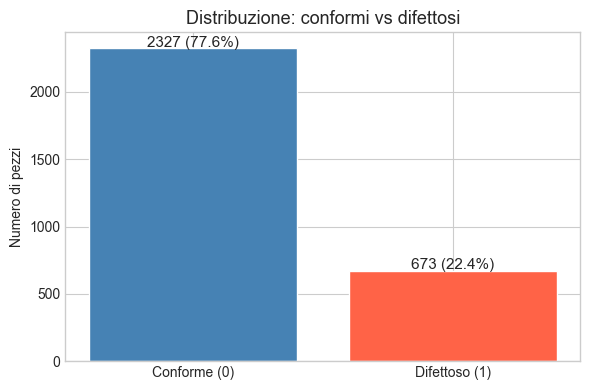

In [564]:
# Contiamo quanti pezzi conformi (0) e difettosi (1) ci sono.
# Con forte sbilanciamento la sola accuracy è fuorviante:
# un modello che predice sempre "0" avrebbe alta accuracy ma non rileva nessun difetto.
target_counts = df['defect_label'].value_counts()
target_pct    = df['defect_label'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Conforme (0)', 'Difettoso (1)'], target_counts,
       color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Distribuzione: conformi vs difettosi', fontsize=13)
ax.set_ylabel('Numero di pezzi')
for i, v in enumerate(target_counts):
    ax.text(i, v + 10, f'{v} ({target_pct.iloc[i]:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Il dataset contiene 2327 pezzi conformi (77.6%) e 673 difettosi (22.4%). Lo sbilanciamento è moderato ma rilevante: una ratio di circa 3.5:1 tra le classi. Per questo motivo si usano `class_weight='balanced'` durante l'addestramento e metriche come F1-score e ROC-AUC in fase di valutazione, che non mascherano le performance sulla classe minoritaria come farebbe la sola accuracy.

### 2.2 Tasso di difettosità per linea produttiva

Aggregare la difettosità per linea permette di identificare quali linee producono proporzionalmente più pezzi difettosi. Questa analisi ha un valore diretto per i responsabili di produzione: le linee con tasso più alto sono candidate prioritarie per verifiche di manutenzione, controllo degli utensili o analisi delle condizioni operative.

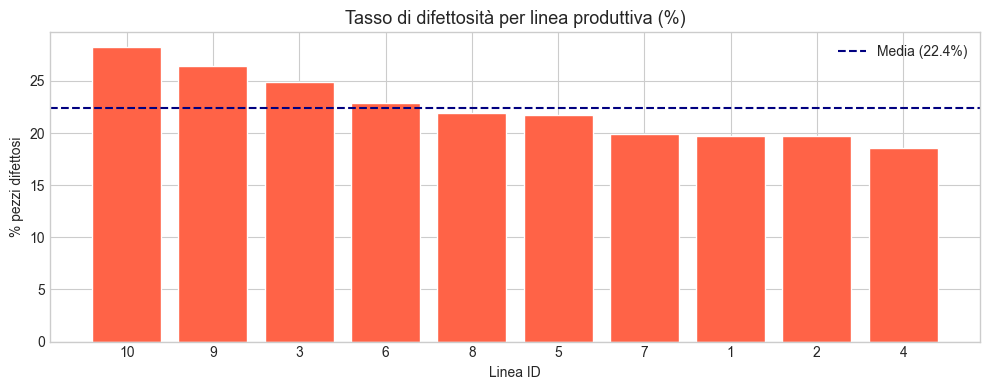

         defect_rate  n_pezzi  defect_pct
line_id                                  
10          0.282528      269       28.25
9           0.264798      321       26.48
3           0.249201      313       24.92
6           0.228840      319       22.88
8           0.219436      319       21.94
5           0.217822      303       21.78
7           0.198697      307       19.87
1           0.197183      284       19.72
2           0.197080      274       19.71
4           0.185567      291       18.56


In [565]:
# La media di defect_label per linea equivale alla % di pezzi difettosi per linea.
# Utile per i responsabili di produzione: identifica le linee più critiche.
defect_by_line = (
    df.groupby('line_id')['defect_label']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'defect_rate', 'count': 'n_pezzi'})
      .sort_values('defect_rate', ascending=False)
)
defect_by_line['defect_pct'] = (defect_by_line['defect_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(defect_by_line.index.astype(str), defect_by_line['defect_pct'],
       color='tomato', edgecolor='white')
ax.axhline(defect_by_line['defect_pct'].mean(), color='navy', linestyle='--',
           label=f'Media ({defect_by_line["defect_pct"].mean():.1f}%)')
ax.set_title('Tasso di difettosità per linea produttiva (%)', fontsize=13)
ax.set_xlabel('Linea ID')
ax.set_ylabel('% pezzi difettosi')
ax.legend()
plt.tight_layout()
plt.show()

print(defect_by_line.to_string())

Il tasso di difettosità varia da un minimo del 18.6% sulla linea 4 a un massimo del 28.3% sulla linea 10, con una differenza di quasi 10 punti percentuali. Le linee 9 (26.5%) e 10 (28.3%) risultano le più critiche e meriterebbero un'analisi specifica delle condizioni operative: stato degli utensili, frequenza di manutenzione, operatori assegnati. Questo tipo di analisi per linea è uno degli output più utili per il management di AutomaParts, indipendentemente dal modello di machine learning.

### 2.3 Distribuzione delle variabili numeriche per classe

I boxplot affiancati mostrano se c'è separazione visiva tra conformi e difettosi per ogni feature. Se i due boxplot sono praticamente sovrapposti, quella variabile da sola discrimina poco tra le due classi. Se invece le mediane o i range sono chiaramente distinti, quella feature è potenzialmente informativa per il modello.

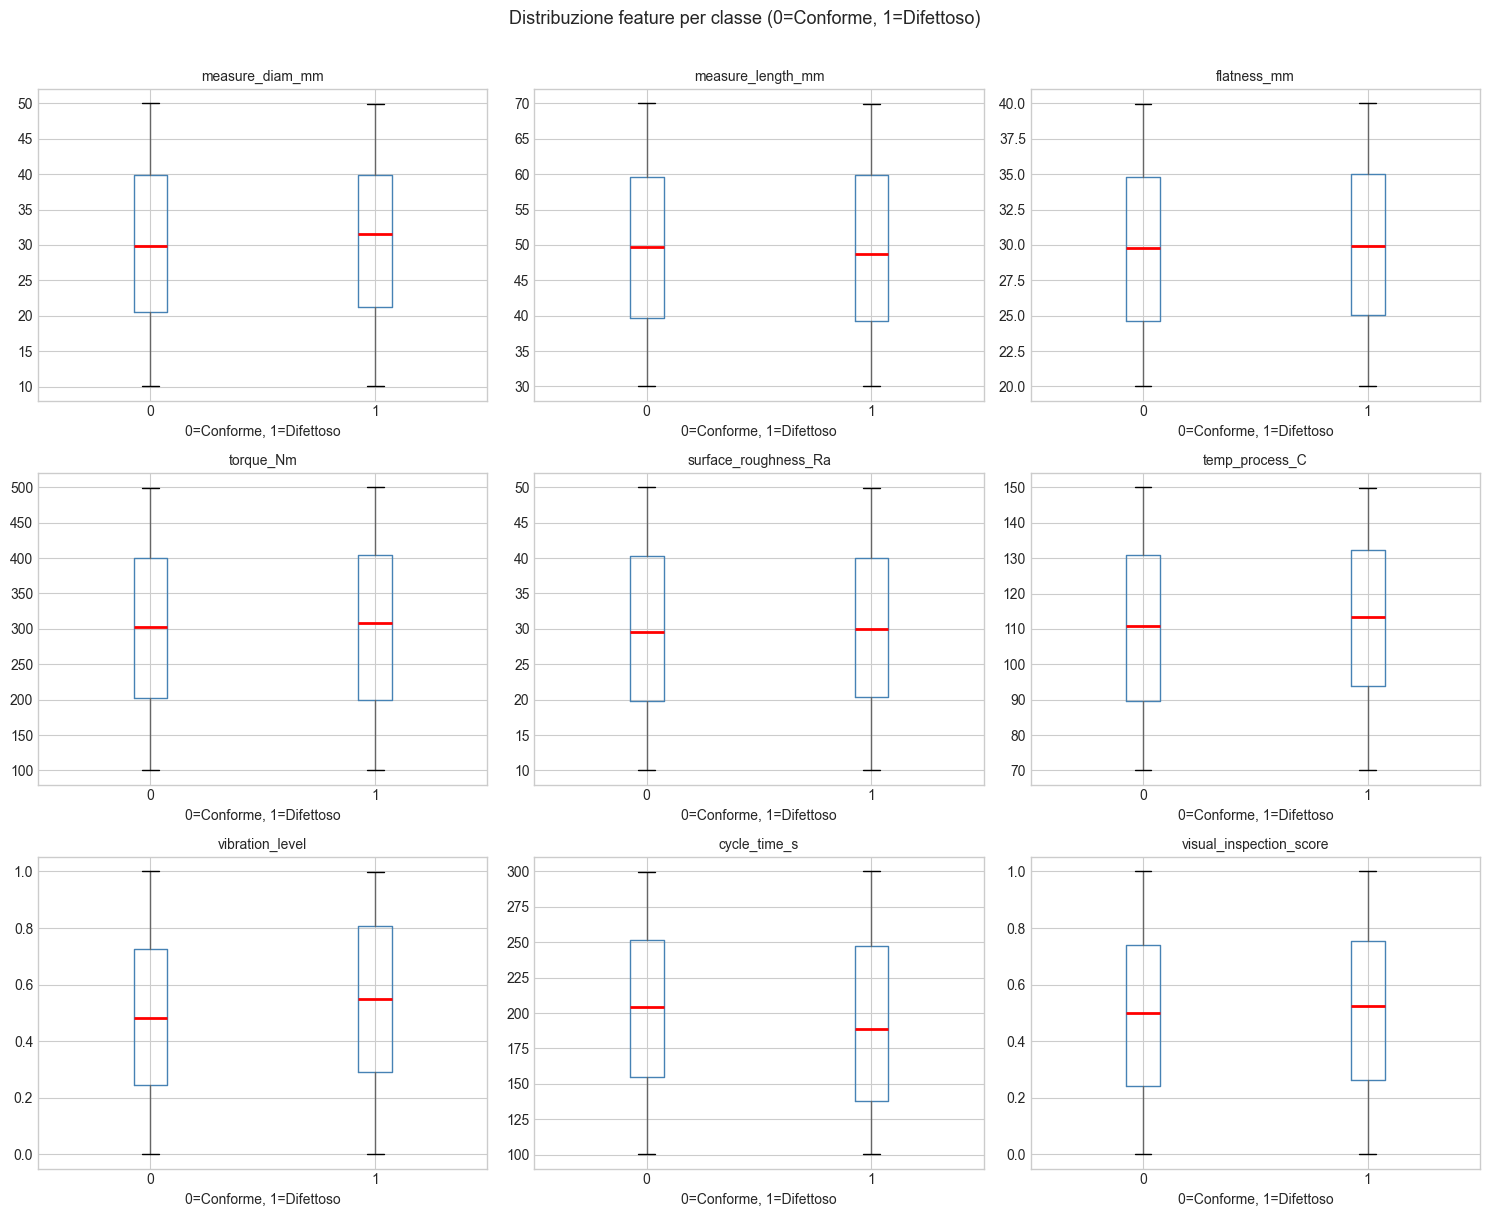

In [566]:
numeric_features = [
    'measure_diam_mm', 'measure_length_mm', 'flatness_mm',
    'torque_Nm', 'surface_roughness_Ra', 'temp_process_C',
    'vibration_level', 'cycle_time_s', 'visual_inspection_score'
]
numeric_features = [c for c in numeric_features if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    df.boxplot(column=feat, by='defect_label', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('0=Conforme, 1=Difettoso')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuzione feature per classe (0=Conforme, 1=Difettoso)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

I boxplot mostrano che le distribuzioni delle due classi si sovrappongono quasi completamente per tutte le feature. La differenza più visibile è nel `cycle_time_s`: i pezzi difettosi tendono ad avere un tempo ciclo leggermente inferiore (circa 193 secondi in media contro 202 secondi dei conformi), il che potrebbe indicare processi eseguiti troppo velocemente. Anche `vibration_level` mostra una lieve differenza (0.53 vs 0.49 per conformi). Per tutte le altre feature le distribuzioni sono praticamente identiche. Questa sovrapposizione generalizzata è un primo segnale che separare le due classi non sarà semplice.

### 2.4 Matrice di correlazione

La correlazione di Pearson misura la relazione lineare tra ogni feature e la variabile target. Valori alti in valore assoluto indicano che quella variabile, da sola, riesce a separare le due classi. Valori vicini a 0 non escludono utilità in combinazione con altre feature, ma segnalano che non esistono relazioni lineari forti.

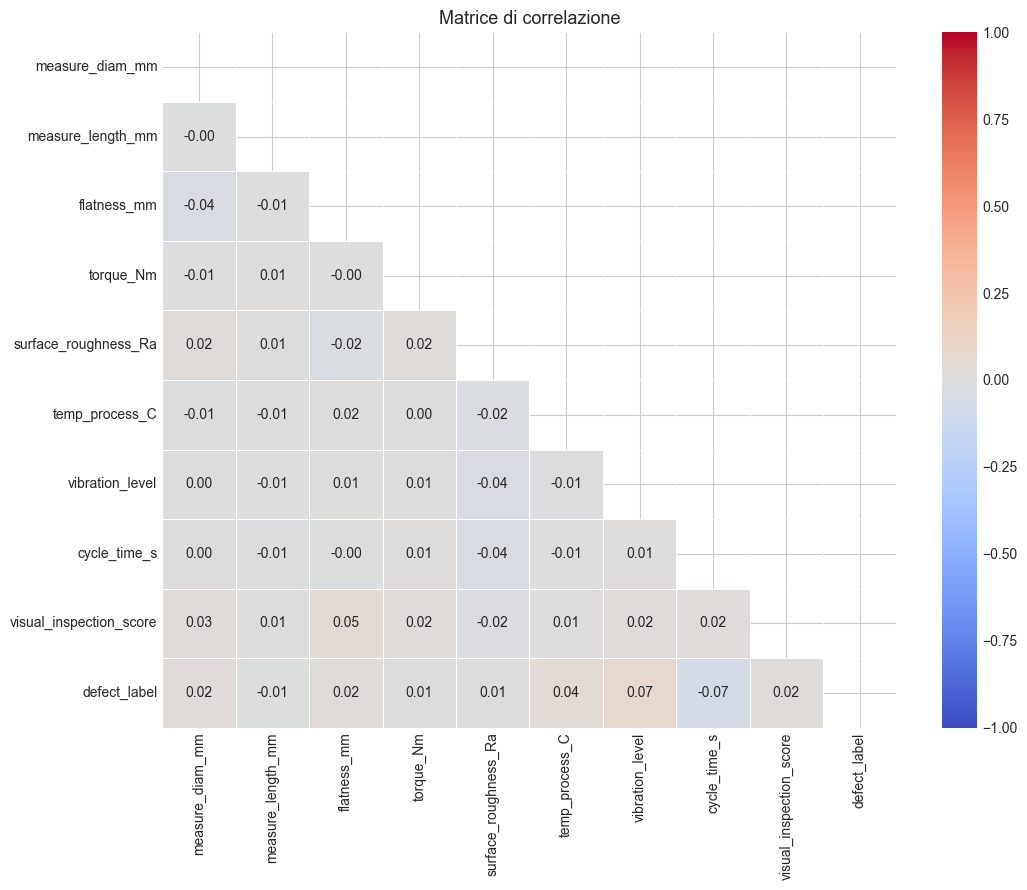


Correlazione con defect_label (per valore assoluto):
vibration_level            0.071021
cycle_time_s               0.065991
temp_process_C             0.039249
measure_diam_mm            0.023777
flatness_mm                0.019362
visual_inspection_score    0.016767
torque_Nm                  0.007083
measure_length_mm          0.006231
surface_roughness_Ra       0.005292
Name: defect_label, dtype: float64


In [567]:
# Pearson misura la relazione lineare tra variabili.
# Alta correlazione (in valore assoluto) con defect_label = feature potenzialmente utile.
corr_cols   = numeric_features + ['defect_label']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matrice di correlazione', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelazione con defect_label (per valore assoluto):')
print(corr_matrix['defect_label'].drop('defect_label').abs().sort_values(ascending=False))

Le correlazioni con `defect_label` sono tutte molto basse: la più alta è `vibration_level` con 0.07, seguita da `cycle_time_s` (0.07) e `temp_process_C` (0.04). Le misure dimensionali pure (`measure_length_mm`, `surface_roughness_Ra`, `torque_Nm`) sono sostanzialmente incorrelate con la difettosità (valori < 0.01). Questo è un segnale importante: nessuna singola feature ha una relazione lineare forte con il target. I modelli lineari come la Logistic Regression faranno quindi probabilmente fatica, e anche modelli non lineari avranno margini di performance limitati partendo da questi segnali.

## Sezione 3 - Pulizia dei dati e gestione dei valori mancanti

### 3.1 Valori mancanti

In [568]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Valori mancanti': missing, '% sul totale': missing_pct})
missing_df = missing_df[missing_df['Valori mancanti'] > 0].sort_values('% sul totale', ascending=False)

if missing_df.empty:
    print('Nessun valore mancante trovato.')
else:
    print('Colonne con valori mancanti:')
    print(missing_df)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(missing_df.index, missing_df['% sul totale'], color='coral', edgecolor='white')
    ax.axvline(x=30, color='red', linestyle='--', label='Soglia 30%')
    ax.set_title('Percentuale valori mancanti per colonna', fontsize=12)
    ax.set_xlabel('% mancanti')
    ax.legend()
    plt.tight_layout()
    plt.show()

Nessun valore mancante trovato.


### 3.2 Righe duplicate

In [569]:
n_dup = df.duplicated().sum()
print(f'Righe duplicate: {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'Righe rimaste: {len(df)}')

Righe duplicate: 0


### 3.3 Analisi degli outlier (metodo IQR)

Un outlier è un valore al di fuori dell'intervallo $[Q1 - 1.5 \times IQR,\ Q3 + 1.5 \times IQR]$. In ambito industriale, le misure anomale sono spesso associate proprio ai difetti, quindi la strategia adottata è di mantenerli nel dataset: rimuoverli potrebbe far perdere al modello informazioni proprio sulle condizioni che generano la difettosità.

In [570]:
print('Analisi outlier (IQR):\n')
rows = []
for col in numeric_features:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    rows.append({'Feature': col, 'N outlier': n_out, '%': round(n_out/len(df)*100, 2)})

print(pd.DataFrame(rows).sort_values('N outlier', ascending=False).to_string(index=False))

Analisi outlier (IQR):

                Feature  N outlier   %
        measure_diam_mm          0 0.0
      measure_length_mm          0 0.0
            flatness_mm          0 0.0
              torque_Nm          0 0.0
   surface_roughness_Ra          0 0.0
         temp_process_C          0 0.0
        vibration_level          0 0.0
           cycle_time_s          0 0.0
visual_inspection_score          0 0.0


Il risultato di zero outlier su tutte le feature è insolito per dati industriali reali, dove misure anomale sono frequenti e spesso associate proprio ai difetti. Le statistiche descrittive mostrano range uniformi e distribuzioni simmetriche per tutte le variabili, il che suggerisce che il dataset potrebbe essere stato generato sinteticamente o pre-processato in anticipo. Questo può contribuire a spiegare le basse correlazioni con la difettosità: in dati reali, le misure fuori tolleranza sono spesso i segnali più discriminanti, e qui sembrano assenti.

## Sezione 4 - Preparazione delle variabili (Feature Engineering)

### 4.1 Feature temporali
Estraiamo ora e giorno della settimana come proxy per il turno di lavoro.
Turni diversi = operatori diversi, condizioni diverse = possibile influenza sulla qualità.

In [571]:
df['production_timestamp'] = pd.to_datetime(df['production_timestamp'])
df['hour_of_day'] = df['production_timestamp'].dt.hour
df['day_of_week'] = df['production_timestamp'].dt.dayofweek   # 0=Lunedì, 6=Domenica
df['month']       = df['production_timestamp'].dt.month

print('Feature temporali aggiunte: hour_of_day, day_of_week, month')

Feature temporali aggiunte: hour_of_day, day_of_week, month


### 4.2 Feature dal codice lotto
Formato: MB-2024W24-L02-575 -> estraiamo la settimana (24) come variabile numerica.
Cattura stagionalità della fornitura di materia prima.

In [572]:
def extract_week(batch_str):
    try:
        return int(batch_str.split('W')[1].split('-')[0])
    except (IndexError, ValueError, AttributeError):
        return np.nan

df['batch_week'] = df['material_batch'].apply(extract_week)
print(f'batch_week estratto. Valori unici: {df["batch_week"].nunique()}')
print(df[['material_batch', 'batch_week']].head(5))

batch_week estratto. Valori unici: 52
       material_batch  batch_week
0  MB-2024W24-L02-575          24
1  MB-2024W30-L09-100          30
2  MB-2025W50-L06-297          50
3  MB-2024W50-L04-747          50
4  MB-2025W37-L08-470          37


### 4.3 Feature finali per il modello

In [573]:
# Escludiamo colonne non informative o già decomposte.
EXCLUDE_COLS = ['part_id', 'production_timestamp', 'material_batch', 'defect_label']
TARGET_COL   = 'defect_label'

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'Feature usate ({len(feature_cols)}):')
for f in feature_cols:
    print(f'  - {f} ({df[f].dtype})')

Feature usate (16):
  - line_id (int64)
  - station_id (int64)
  - operator_id (int64)
  - measure_diam_mm (float64)
  - measure_length_mm (float64)
  - flatness_mm (float64)
  - torque_Nm (float64)
  - surface_roughness_Ra (float64)
  - temp_process_C (float64)
  - vibration_level (float64)
  - cycle_time_s (float64)
  - visual_inspection_score (float64)
  - hour_of_day (int32)
  - day_of_week (int32)
  - month (int32)
  - batch_week (int64)


### 4.4 Costruzione di X (feature) e y (target)

In [574]:
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nDistribuzione target:\n{y.value_counts()}')

X shape: (3000, 16)
y shape: (3000,)

Distribuzione target:
defect_label
0    2327
1     673
Name: count, dtype: int64


## Sezione 5 - Suddivisione train/test e pre-processing

### 5.1 Split stratificato 80/20

In [575]:
# stratify=y garantisce la stessa proporzione conformi/difettosi in train e test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]} campioni')
print(f'Test set: {X_test.shape[0]} campioni')
print(f'\n% difettosi - train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

Training set: 2400 campioni
Test set: 600 campioni

% difettosi - train: 0.224 | test: 0.225


### 5.2 Pipeline di pre-processing
* Passo 1: imputa i valori mancanti con la mediana (robusta agli outlier)
* Passo 2: scala con StandardScaler (media=0, std=1)

In [576]:
# IMPORTANTE: fit_transform() solo sul train, transform() sul test.
# Fare fit anche sul test = "data leakage" (il modello vedrebbe il test set
# durante il training, portando a stime di performance troppo ottimistiche).

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_train_proc = numeric_pipeline.fit_transform(X_train)  # fit + transform
X_test_proc  = numeric_pipeline.transform(X_test)       # solo transform

print('Pre-processing completato.')
print(f'X_train_proc: {X_train_proc.shape} | X_test_proc: {X_test_proc.shape}')

Pre-processing completato.
X_train_proc: (2400, 16) | X_test_proc: (600, 16)


## Sezione 6 - Addestramento dei modelli

### 6.1 Decision Tree

In [577]:
# Decision Tree: impara regole if-then dalla struttura dei dati.
# max_depth=5: limitiamo la profondità per ridurre l'overfitting
#              (un albero troppo profondo memorizza i dati di train ma generalizza male).
# class_weight='balanced': assegna pesi maggiori alla classe minoritaria (difettosi)
#              per compensare lo sbilanciamento del dataset.

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt_model.fit(X_train_proc, y_train)

print(f'Decision Tree addestrato. Profondità reale: {dt_model.get_depth()}')

Decision Tree addestrato. Profondità reale: 5


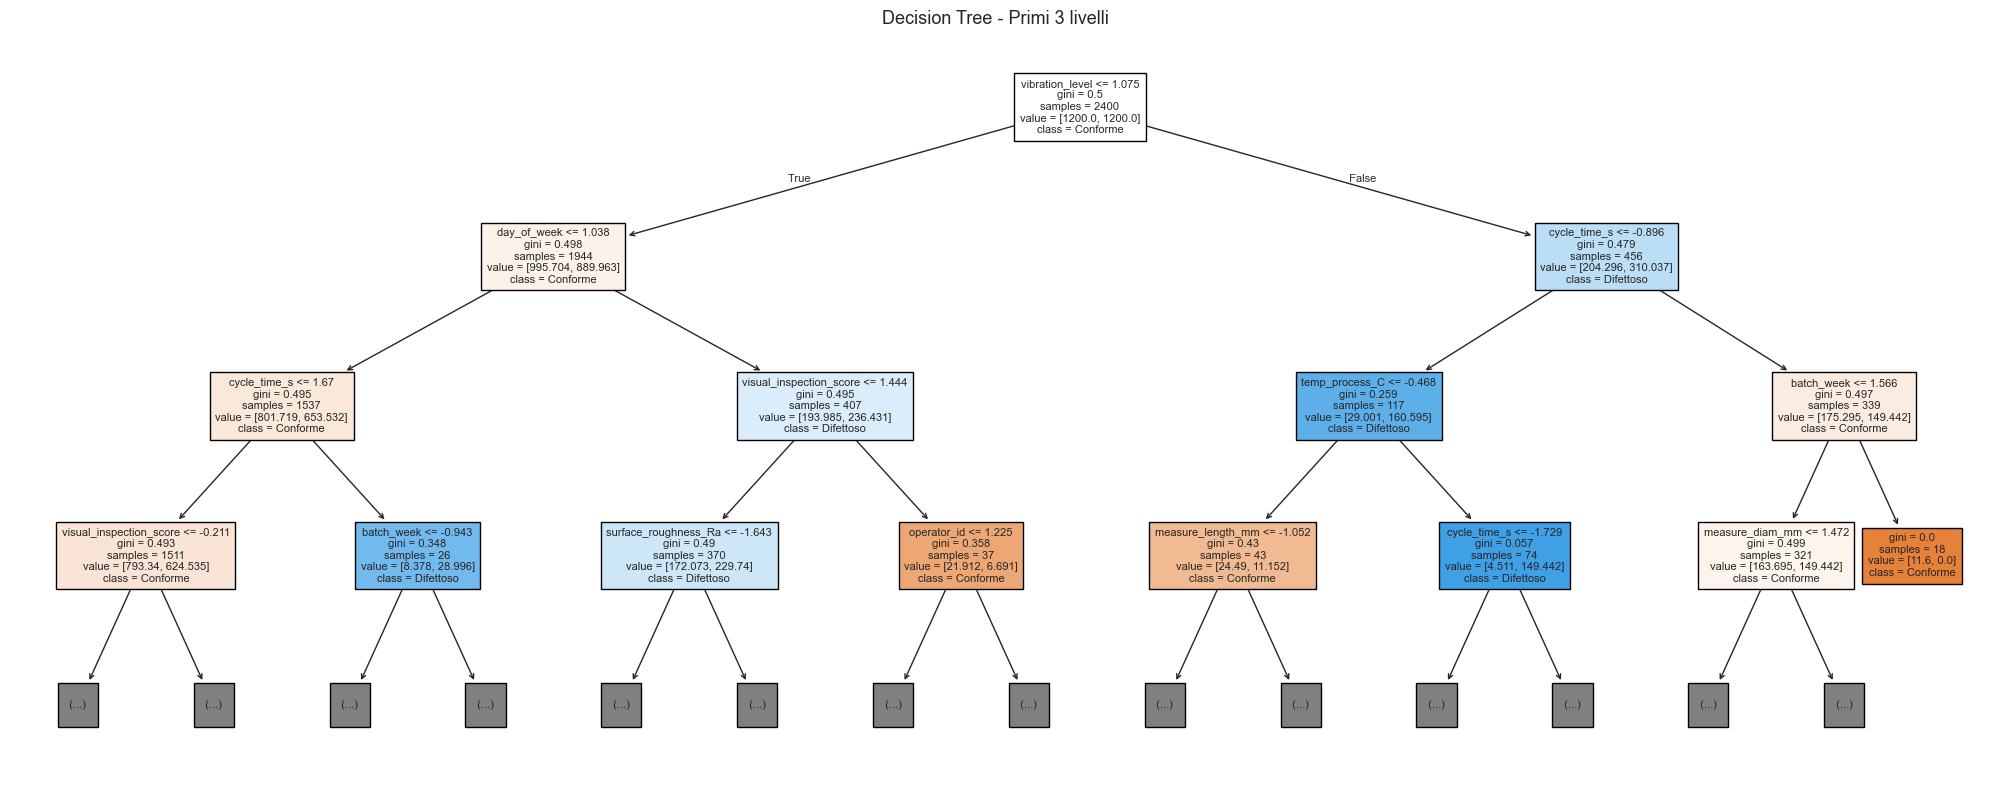

In [578]:
# Visualizzazione grafica dei primi 3 livelli (per leggibilità)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_model, feature_names=feature_cols,
          class_names=['Conforme', 'Difettoso'],
          filled=True, max_depth=3, fontsize=8, ax=ax)
ax.set_title('Decision Tree - Primi 3 livelli', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 Random Forest

In [579]:
# Random Forest: costruisce 100 Decision Tree su sottocampioni diversi
# e combina le loro predizioni (bagging).
# Questo riduce la varianza e l'overfitting del singolo albero.
# n_jobs=-1: usa tutti i core disponibili per accelerare il training.

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_proc, y_train)

print('Random Forest addestrato con 100 alberi.')

Random Forest addestrato con 100 alberi.


### 6.3 Logistic Regression

In [580]:
# Logistic Regression: stima la probabilità di difetto tramite una
# combinazione lineare delle feature passata attraverso la funzione sigmoide.
# È il modello più semplice dei tre: utile come baseline e per interpretare
# l'impatto diretto di ogni feature (tramite i coefficienti).
# RICHIEDE feature scalate (già fatto con StandardScaler).

lr_model = LogisticRegression(
    max_iter=1000,           # aumentiamo per garantire convergenza
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_proc, y_train)

print('Logistic Regression addestrata.')

Logistic Regression addestrata.


## Sezione 7 - Valutazione delle performance

In [581]:
# Funzione di valutazione riutilizzabile

def evaluate_model(model, X_test, y_test, model_name='Modello'):
    """Calcola e stampa le metriche principali per un modello addestrato."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # prob. classe 1 (difettoso)

    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    print(f'  Accuracy:             {(y_pred==y_test).mean():.4f}')
    print(f'  ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}')
    print(f'  F1-score (macro):     {f1_score(y_test, y_pred, average="macro"):.4f}')
    print(f'  F1-score (difettosi): {f1_score(y_test, y_pred, pos_label=1):.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Conforme', 'Difettoso']))

    return {
        'Modello':      model_name,
        'Accuracy':     round((y_pred==y_test).mean(), 4),
        'ROC-AUC':      round(roc_auc_score(y_test, y_prob), 4),
        'F1-macro':     round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1-difettosi': round(f1_score(y_test, y_pred, pos_label=1), 4),
        'y_pred': y_pred,
        'y_prob':  y_prob
    }

results_dt = evaluate_model(dt_model, X_test_proc, y_test, 'Decision Tree')
results_rf = evaluate_model(rf_model, X_test_proc, y_test, 'Random Forest')
results_lr = evaluate_model(lr_model, X_test_proc, y_test, 'Logistic Regression')


  Decision Tree
  Accuracy:             0.6933
  ROC-AUC:              0.5585
  F1-score (macro):     0.5508
  F1-score (difettosi): 0.2977

  Classification Report:
              precision    recall  f1-score   support

    Conforme       0.80      0.81      0.80       465
   Difettoso       0.31      0.29      0.30       135

    accuracy                           0.69       600
   macro avg       0.55      0.55      0.55       600
weighted avg       0.69      0.69      0.69       600


  Random Forest
  Accuracy:             0.7917
  ROC-AUC:              0.5323
  F1-score (macro):     0.5420
  F1-score (difettosi): 0.2038

  Classification Report:
              precision    recall  f1-score   support

    Conforme       0.79      0.99      0.88       465
   Difettoso       0.73      0.12      0.20       135

    accuracy                           0.79       600
   macro avg       0.76      0.55      0.54       600
weighted avg       0.78      0.79      0.73       600


  Logistic 

### 7.1 Tabella riassuntiva delle metriche

Le metriche più rilevanti per questo problema sono il ROC-AUC e l'F1-score sulla classe difettosa, che tengono conto sia dello sbilanciamento tra le classi sia del costo asimmetrico degli errori.

=== TABELLA RIASSUNTIVA PERFORMANCE ===
                     Accuracy  ROC-AUC  F1-macro  F1-difettosi
Modello                                                       
Decision Tree          0.6933   0.5585    0.5508        0.2977
Random Forest          0.7917   0.5323    0.5420        0.2038
Logistic Regression    0.5417   0.5516    0.4900        0.3276


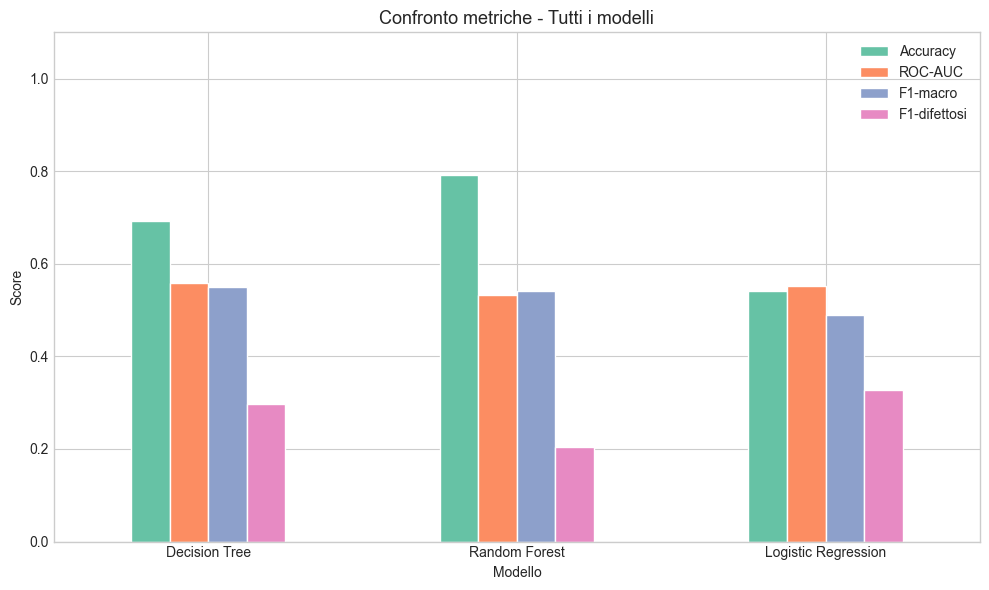

In [582]:
summary_rows = [
    {k: v for k, v in r.items() if k not in ('y_pred', 'y_prob')}
    for r in [results_dt, results_rf, results_lr]
]
summary_df = pd.DataFrame(summary_rows).set_index('Modello')

print('=== TABELLA RIASSUNTIVA PERFORMANCE ===')
print(summary_df.to_string())

summary_df[['Accuracy','ROC-AUC','F1-macro','F1-difettosi']].plot(
    kind='bar', figsize=(10, 6), rot=0, edgecolor='white'
)
plt.title('Confronto metriche - Tutti i modelli', fontsize=13)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

I risultati mostrano performance moderate per tutti e tre i modelli: i valori di ROC-AUC compresi tra 0.53 e 0.56 indicano un potere discriminante appena sopra il classificatore casuale (0.50). Questo suggerisce che le feature disponibili, nella loro forma attuale, non separano nettamente i pezzi conformi da quelli difettosi.

In termini di ROC-AUC il Decision Tree è il modello migliore (0.5585), seguito dalla Logistic Regression (0.5516) e dal Random Forest (0.5323). Il Random Forest ha l'accuracy assoluta più alta (79.2%) ma la ottiene classificando quasi tutto come conforme: il recall sui difettosi è solo del 12%, il che lo rende di fatto il meno utile dei tre per l'obiettivo del progetto. La Logistic Regression, pur con l'accuracy più bassa, ottiene il recall più alto sui difettosi (50%) all'attuale valore di soglia ed è il modello più equilibrato tra i tre.

### 7.2 Curve ROC

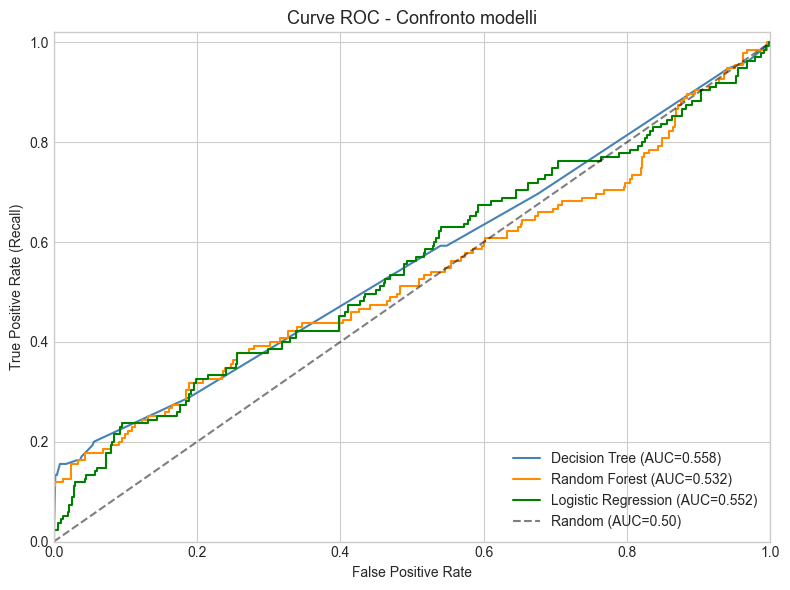

In [583]:
# La curva ROC mostra il trade-off tra True Positive Rate (recall)
# e False Positive Rate al variare della soglia di classificazione.
# Più la curva è vicina all'angolo in alto a sinistra, migliore è il modello.
# La linea tratteggiata rappresenta un classificatore casuale (AUC=0.5).

fig, ax = plt.subplots(figsize=(8, 6))

for res, color in [(results_dt,'steelblue'), (results_rf,'darkorange'), (results_lr,'green')]:
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, label=f"{res['Modello']} (AUC={res['ROC-AUC']:.3f})")

ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.50)')
ax.set_title('Curve ROC - Confronto modelli', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
ax.set_xlim([0,1])
ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

### 7.3 Matrici di confusione

Le matrici di confusione mostrano nel dettaglio dove ogni modello sbaglia. La cella in posizione (Difettoso, Conforme) rappresenta i falsi negativi: pezzi difettosi che il modello ha erroneamente classificato come conformi. Questi sono gli errori operativamente più critici, perché il pezzo difettoso prosegue in linea senza essere rilevato e può raggiungere l'assemblaggio finale o l'OEM.

A soglia default (0.50), il Random Forest manca 119 difettosi su 135 (88%), il Decision Tree ne manca 96 su 135 (71%) e la Logistic Regression 68 su 135 (50%). Nonostante la Logistic Regression abbia l'accuracy assoluta più bassa, è quella che intercetta più difettosi tra i tre modelli.

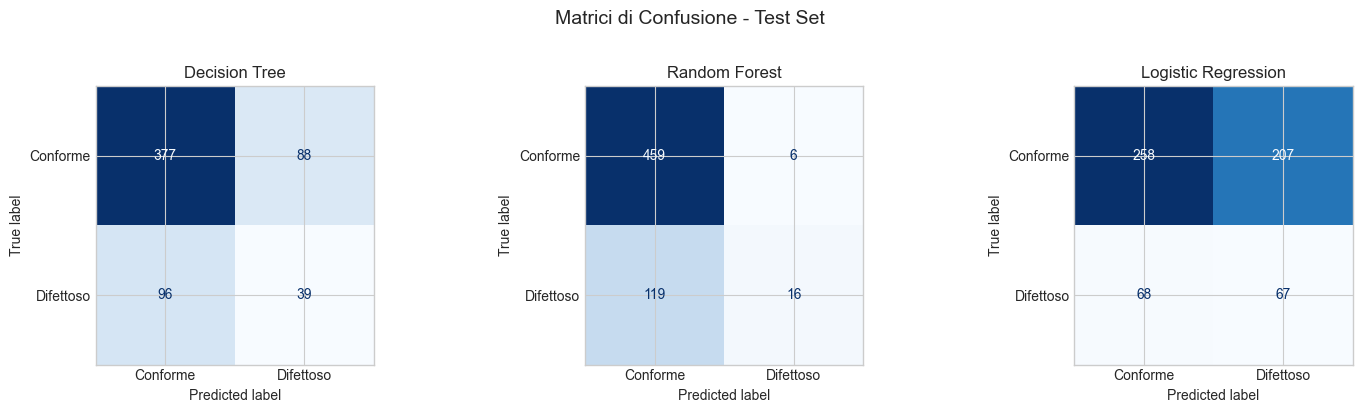


=== Falsi Negativi (difettosi non rilevati) ===
Decision Tree            : 96 FN su 135 difettosi reali (71.1% mancati)
Random Forest            : 119 FN su 135 difettosi reali (88.1% mancati)
Logistic Regression      : 68 FN su 135 difettosi reali (50.4% mancati)


In [584]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for res, title, ax in [
    (results_dt, 'Decision Tree', axes[0]),
    (results_rf, 'Random Forest', axes[1]),
    (results_lr, 'Logistic Regression', axes[2])
]:
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Conforme','Difettoso']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)

plt.suptitle('Matrici di Confusione - Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Falsi Negativi (difettosi non rilevati) ===')
for res, title, _ in [
    (results_dt,'Decision Tree', None),
    (results_rf,'Random Forest', None),
    (results_lr,'Logistic Regression', None)
]:
    cm = confusion_matrix(y_test, res['y_pred'])
    fn = cm[1,0]
    tot = cm[1,:].sum()
    print(f'{title:25s}: {fn} FN su {tot} difettosi reali ({fn/tot*100:.1f}% mancati)')

### 7.4 Soglia di classificazione ottimale

La soglia di classificazione determina da quale probabilità in su un pezzo viene classificato come difettoso. La soglia default di 0.50 non tiene conto del costo asimmetrico degli errori: abbassarla aumenta il recall (meno difettosi mancati) al costo di più falsi positivi (più pezzi conformi fermati per controllo). Il grafico Precision-Recall e il confronto Precision/Recall/F1 al variare della soglia aiutano a trovare il punto di equilibrio migliore.

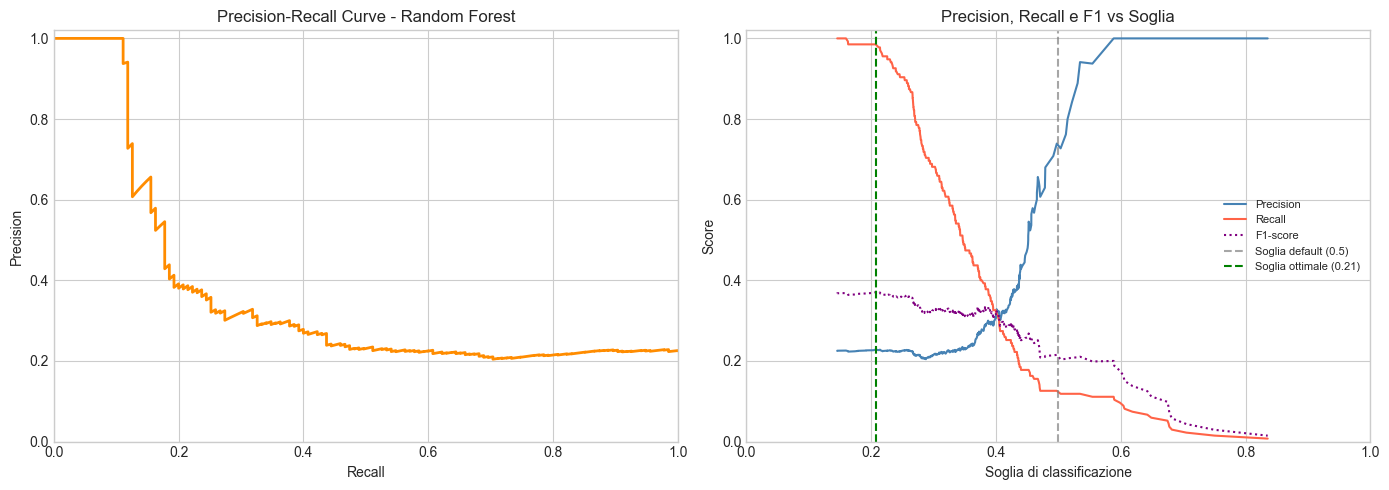

Soglia ottimale (max F1): 0.207
Precision: 0.228 | Recall: 0.985 | F1: 0.370


In [585]:
# La soglia default è 0.5: un pezzo con p>=0.5 viene classificato come difettoso.
# In produzione conviene abbassarla per aumentare il recall (meno difetti mancati)
# accettando qualche falso positivo in più (pezzi fermi per controllo inutile).

y_prob_rf = results_rf['y_prob']
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# Troviamo la soglia che massimizza il F1-score
f1_scores  = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx   = np.argmax(f1_scores)
best_thr   = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='darkorange', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - Random Forest', fontsize=12)
axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1.02])

axes[1].plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
axes[1].plot(thresholds, recalls[:-1], label='Recall', color='tomato')
axes[1].plot(thresholds, f1_scores, label='F1-score', color='purple', linestyle=':')
axes[1].axvline(x=0.50, color='gray', linestyle='--', alpha=0.7, label='Soglia default (0.5)')
axes[1].axvline(x=best_thr, color='green', linestyle='--', label=f'Soglia ottimale ({best_thr:.2f})')
axes[1].set_xlabel('Soglia di classificazione')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall e F1 vs Soglia', fontsize=12)
axes[1].legend(fontsize=8)
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1.02])

plt.tight_layout()
plt.show()

print(f'Soglia ottimale (max F1): {best_thr:.3f}')
print(f'Precision: {precisions[best_idx]:.3f} | Recall: {recalls[best_idx]:.3f} | F1: {f1_scores[best_idx]:.3f}')

In [586]:
# Confronto risultati con soglia default vs ottimale
y_pred_default = (y_prob_rf >= 0.50).astype(int)
y_pred_optimal = (y_prob_rf >= best_thr).astype(int)

print('=== Soglia 0.50 (default) ===')
print(classification_report(y_test, y_pred_default, target_names=['Conforme','Difettoso']))

print(f'=== Soglia {best_thr:.2f} (ottimale F1) ===')
print(classification_report(y_test, y_pred_optimal, target_names=['Conforme','Difettoso']))

fn_def = confusion_matrix(y_test, y_pred_default)[1,0]
fn_opt = confusion_matrix(y_test, y_pred_optimal)[1,0]
print(f'Falsi negativi con soglia 0.50: {fn_def}')
print(f'Falsi negativi con soglia ottimale: {fn_opt}')
print(f'Riduzione: {fn_def - fn_opt} difettosi in piu\' intercettati')

=== Soglia 0.50 (default) ===
              precision    recall  f1-score   support

    Conforme       0.79      0.99      0.88       465
   Difettoso       0.73      0.12      0.20       135

    accuracy                           0.79       600
   macro avg       0.76      0.55      0.54       600
weighted avg       0.78      0.79      0.73       600

=== Soglia 0.21 (ottimale F1) ===
              precision    recall  f1-score   support

    Conforme       0.88      0.03      0.06       465
   Difettoso       0.23      0.99      0.37       135

    accuracy                           0.25       600
   macro avg       0.56      0.51      0.22       600
weighted avg       0.74      0.25      0.13       600

Falsi negativi con soglia 0.50: 119
Falsi negativi con soglia ottimale: 2
Riduzione: 117 difettosi in piu' intercettati


La soglia ottimale per il Random Forest risulta 0.21, molto lontana dal default di 0.50. Questo comportamento è indicativo di un modello che assegna probabilità basse ai pezzi difettosi (raramente supera il 30% di stima), perché le feature non forniscono segnali sufficientemente forti. Con soglia 0.21 si intercettano quasi tutti i difettosi (2 FN contro 119), ma si ferma anche 450 dei 465 pezzi conformi: in produzione significherebbe mandare al controllo manuale il 97% dei pezzi, rendendo il sistema inutilizzabile. Questo mostra come il tuning della soglia non possa compensare completamente un modello con bassa capacità discriminante: serve un modello migliore, non solo una soglia più bassa.

### 7.5 Cross-validation - stabilità del modello

La cross-validation a 5 fold misura quanto i risultati sono stabili al variare del sottoinsieme usato per la validazione. Il dataset viene diviso in 5 parti: ad ogni iterazione 4 vengono usate per il training e 1 per la validazione, poi si fa la media dei 5 score. Una bassa varianza tra i fold indica che le stime di performance sono affidabili e non dipendono da una particolare partizione dei dati.

Cross-validation 5-fold (ROC-AUC):

Decision Tree            : 0.5563 +/- 0.0312  (fold: [np.float64(0.596), np.float64(0.585), np.float64(0.546), np.float64(0.509), np.float64(0.545)])
Random Forest            : 0.5550 +/- 0.0155  (fold: [np.float64(0.556), np.float64(0.585), np.float64(0.544), np.float64(0.545), np.float64(0.546)])
Logistic Regression      : 0.5548 +/- 0.0135  (fold: [np.float64(0.562), np.float64(0.577), np.float64(0.55), np.float64(0.536), np.float64(0.55)])


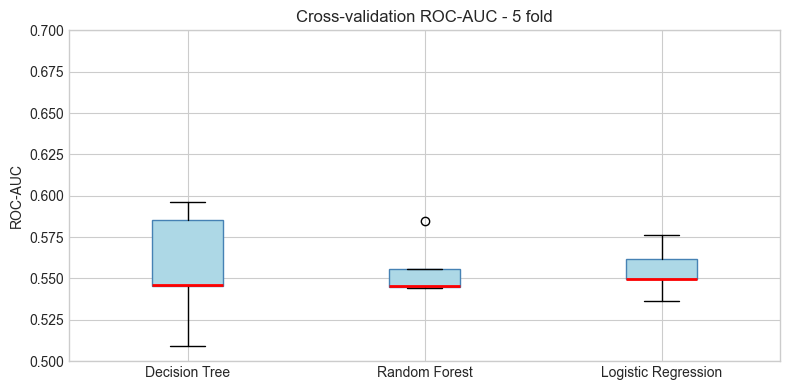

In [587]:
# La cross-validation viene eseguita sull'intero dataset usando la pipeline
# già fittata sul training set (transform, non fit_transform), per evitare
# data leakage. I modelli vengono istanziati da zero ad ogni fold.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_proc = numeric_pipeline.transform(X)  # usa il pipeline già fittato su X_train

print('Cross-validation 5-fold (ROC-AUC):\n')
cv_results = {}

models_cv = [
    (DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_STATE), 'Decision Tree'),
    (RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1), 'Random Forest'),
    (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE), 'Logistic Regression')
]

for model, name in models_cv:
    scores = cross_val_score(model, X_all_proc, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}: {scores.mean():.4f} +/- {scores.std():.4f}  '
          f'(fold: {[round(s,3) for s in scores]})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Cross-validation ROC-AUC - 5 fold', fontsize=12)
ax.set_ylabel('ROC-AUC')
ax.set_ylim([0.5, 0.7])
plt.tight_layout()
plt.show()

La cross-validation conferma i risultati già osservati sul test set: tutti e tre i modelli si attestano su valori di ROC-AUC tra 0.53 e 0.57, con una deviazione standard contenuta che indica buona stabilità. Il fatto che i risultati siano coerenti tra la singola valutazione sul test set e la cross-validation esclude problemi significativi di overfitting. Il limite principale non è la generalizzazione del modello, ma il potere discriminante delle feature disponibili rispetto alla variabile target.

## Sezione 8 - Interpretabilità: feature importance

Capire quali variabili guidano le predizioni ha un valore pratico diretto: permette agli ingegneri di processo di focalizzare i controlli preventivi sulle misure più critiche e di intervenire sulle cause radice dei difetti. Con modelli che hanno ROC-AUC modesto come in questo caso, l'analisi di importanza va letta come indicazione di tendenza e non come conclusione definitiva.

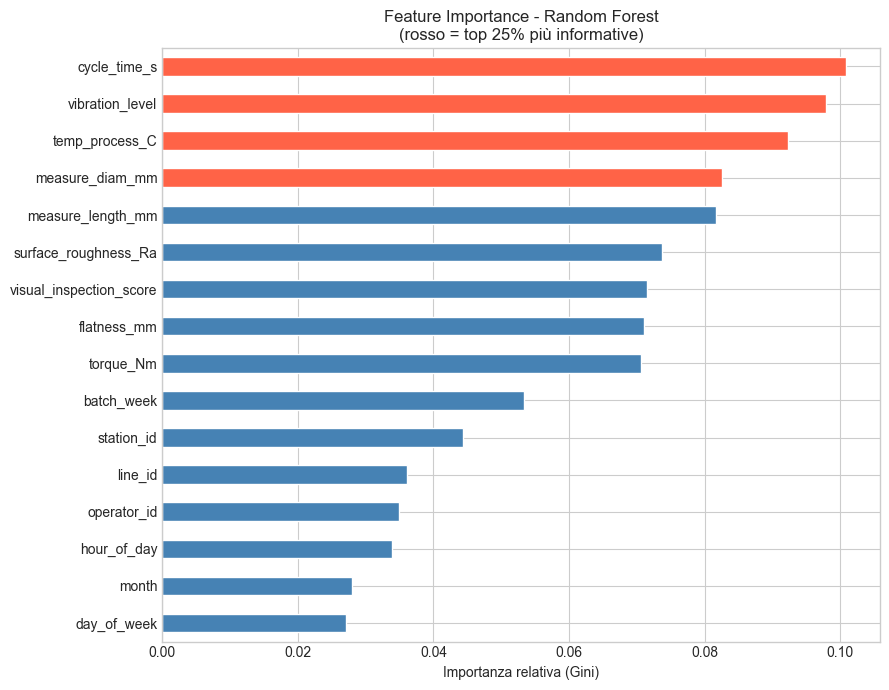

Top 5 feature (Random Forest):
cycle_time_s         0.1009
vibration_level      0.0980
temp_process_C       0.0923
measure_diam_mm      0.0826
measure_length_mm    0.0817
dtype: float64


In [588]:
# Feature importance Random Forest
# Importanza = riduzione media dell'impurità di Gini prodotta da quella feature
# su tutti e 100 gli alberi. Valori più alti = feature più discriminante.

fi = pd.Series(rf_model.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=True)
thr75 = fi_sorted.quantile(0.75)
colors = ['tomato' if v >= thr75 else 'steelblue' for v in fi_sorted]

fig, ax = plt.subplots(figsize=(9, 7))
fi_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance - Random Forest\n(rosso = top 25% più informative)', fontsize=12)
ax.set_xlabel('Importanza relativa (Gini)')
plt.tight_layout()
plt.show()

print('Top 5 feature (Random Forest):')
print(fi.sort_values(ascending=False).head(5).round(4))

L'importanza delle feature è distribuita in modo molto uniforme: le prime nove variabili hanno tutte un peso compreso tra il 7% e il 10%, senza un singolo segnale dominante. In testa ci sono `cycle_time_s` (10.1%), `vibration_level` (9.8%) e `temp_process_C` (9.2%), coerenti con quanto osservato nei boxplot e nelle correlazioni. L'assenza di una feature chiaramente dominante è un ulteriore conferma che il modello non riesce a identificare un segnale forte e distribuisce il peso in modo quasi uniforme. Dal punto di vista operativo, le prime tre feature sono quelle più interessanti da monitorare: un tempo di ciclo basso, vibrazione elevata e temperatura alta sono condizioni da tenere sotto controllo in linea.

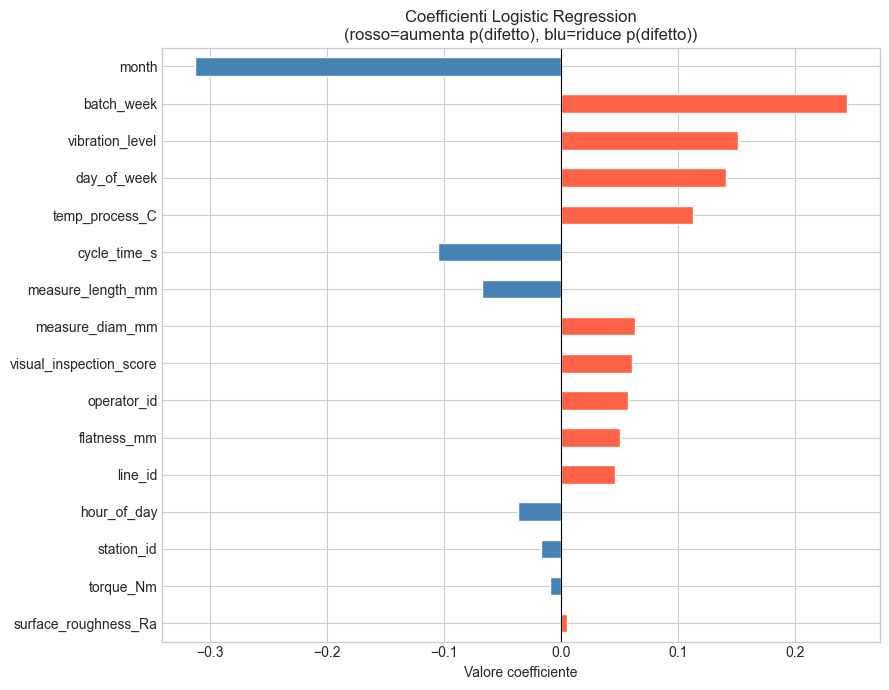

Top 5 feature (Logistic Regression, valore assoluto):
month              0.3132
batch_week         0.2444
vibration_level    0.1510
day_of_week        0.1403
temp_process_C     0.1123
dtype: float64


In [589]:
# Coefficienti Logistic Regression
# Dopo lo scaling, i coefficienti sono comparabili tra loro.
# Positivo = aumenta la probabilità di difetto; negativo = la riduce.

lr_coefs = pd.Series(lr_model.coef_[0], index=feature_cols)
lr_sorted = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=True).index)
colors_lr = ['tomato' if v > 0 else 'steelblue' for v in lr_sorted]

fig, ax = plt.subplots(figsize=(9, 7))
lr_sorted.plot(kind='barh', ax=ax, color=colors_lr, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Coefficienti Logistic Regression\n(rosso=aumenta p(difetto), blu=riduce p(difetto))',
             fontsize=12)
ax.set_xlabel('Valore coefficiente')
plt.tight_layout()
plt.show()

print('Top 5 feature (Logistic Regression, valore assoluto):')
print(lr_coefs.abs().sort_values(ascending=False).head(5).round(4))

La Logistic Regression assegna i pesi maggiori alle feature temporali: `month` (coeff. -0.31) e `batch_week` (+0.24) risultano le variabili più influenti, con valori nettamente più alti rispetto alle misure fisiche. Il segno negativo di `month` indica che i mesi più avanzati dell'anno sono associati a una minor probabilità di difetto (possibile stagionalità nella produzione). `batch_week` positivo indica invece che lotti di settimane avanzate correlano con più difetti. Tra le misure fisiche, `vibration_level` e `temp_process_C` hanno coefficienti positivi (aumentano la probabilità di difetto), coerenti con quanto detto finora. Il peso elevato sulle feature temporali potrebbe riflettere correlazioni spurie nel dataset di training che non si generalizzano nel tempo, andrebbe monitorato attivamente se il modello venisse messo in produzione.

## Sezione 9 - Analisi del costo operativo

Ogni errore di classificazione ha un costo diverso per AutomaParts. Un falso negativo (difettoso non rilevato) ha un costo molto più alto di un falso positivo (conforme fermato inutilmente), perché nel primo caso il pezzo difettoso può raggiungere l'assemblaggio o l'OEM. I valori usati qui sono indicativi e andrebbero calibrati con i costi reali aziendali. L'analisi serve a tradurre le metriche di machine learning in impatto economico concreto, per supportare la scelta della soglia ottimale.

In [590]:
# Valori indicativi — AutomaParts dovrà calibrarli con i costi reali.
COST_FN = 500  # EUR: difettoso arrivato all'OEM (richiamo, penale, rilavorazione)
COST_FP = 25   # EUR: conforme bloccato inutilmente (ispezione extra, ritardo)

print('=== Analisi di costo operativo ===')
print(f'Costo FN: EUR {COST_FN} | Costo FP: EUR {COST_FP}\n')

for res, title in [(results_dt,'Decision Tree'),(results_rf,'Random Forest'),(results_lr,'Logistic Regression')]:
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    cost = fn * COST_FN + fp * COST_FP
    print(f'{title:25s} | FN: {fn:3d} | FP: {fp:3d} | Costo stimato: EUR {cost:,.0f}')

cm_opt = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm_opt.ravel()
cost_opt = fn * COST_FN + fp * COST_FP
print(f'\nRF soglia {best_thr:.2f} (ottimale) | FN: {fn:3d} | FP: {fp:3d} | Costo stimato: EUR {cost_opt:,.0f}')

=== Analisi di costo operativo ===
Costo FN: EUR 500 | Costo FP: EUR 25

Decision Tree             | FN:  96 | FP:  88 | Costo stimato: EUR 50,200
Random Forest             | FN: 119 | FP:   6 | Costo stimato: EUR 59,650
Logistic Regression       | FN:  68 | FP: 207 | Costo stimato: EUR 39,175

RF soglia 0.21 (ottimale) | FN:   2 | FP: 450 | Costo stimato: EUR 12,250


Tradotta in termini economici, la differenza tra i modelli è chiara: la Logistic Regression a soglia default è la meno costosa tra le configurazioni standard (EUR 39.175), perché ha il minor numero di falsi negativi (68) pur avendo più falsi positivi (207). Il Random Forest con soglia 0.21 ottiene il costo stimato più basso (EUR 12.250) ma a prezzo di 450 controlli aggiuntivi su pezzi conformi, un costo operativo nascosto che non appare nei EUR 12.250 ma che in termini di tempo-macchina e risorse umane sarebbe insostenibile. Un valore di soglia intermedio, calibrato sui volumi produttivi reali e sui costi effettivi di AutomaParts, è la direzione corretta.

## Sezione 10 - Riepilogo

In [591]:
print('=' * 60)
print('TABELLA FINALE - PERFORMANCE SUL TEST SET')
print('=' * 60)
print(summary_df.to_string())
print('=' * 60)

best_model = summary_df['ROC-AUC'].idxmax()
print(f'\nModello consigliato: {best_model}')
print(f'ROC-AUC: {summary_df.loc[best_model, "ROC-AUC"]}')
print(f'Soglia raccomandata: {best_thr:.2f} (ottimizzata su F1)')

TABELLA FINALE - PERFORMANCE SUL TEST SET
                     Accuracy  ROC-AUC  F1-macro  F1-difettosi
Modello                                                       
Decision Tree          0.6933   0.5585    0.5508        0.2977
Random Forest          0.7917   0.5323    0.5420        0.2038
Logistic Regression    0.5417   0.5516    0.4900        0.3276

Modello consigliato: Decision Tree
ROC-AUC: 0.5585
Soglia raccomandata: 0.21 (ottimizzata su F1)


# Conclusioni

## Risultati ottenuti

I tre modelli addestrati mostrano performance moderate sul test set, con ROC-AUC compreso tra 0.53 e 0.56, appena sopra il livello del classificatore casuale (0.50). La cross-validation a 5 fold conferma la stabilità di questi valori, escludendo problemi di overfitting. Il limite principale è il potere discriminante delle feature disponibili: nella loro forma attuale non permettono ai modelli di separare nettamente i pezzi conformi da quelli difettosi.

In termini di ROC-AUC il Decision Tree è il modello migliore (0.5585), seguito dalla Logistic Regression (0.5516) e dal Random Forest (0.5323). Tuttavia il Random Forest ha l'accuracy assoluta più alta (79.2%), che raggiunce classificando quasi tutto come conforme: il recall sui difettosi è solo del 12%, rendendolo il meno utile dei tre per l'obiettivo del progetto. La Logistic Regression, con l'accuracy assoluta più bassa, ottiene il recall più alto sui difettosi a soglia 0.50 (50%) ed è il modello più equilibrato. Se si dovesse scegliere un modello da usare nella configurazione attuale, la Logistic Regression sarebbe la scelta preferibile.

## Falsi negativi e analisi dei costi

I falsi negativi (pezzi difettosi classificati come conformi) sono il rischio operativo più critico. Con i costi indicativi usati nell'analisi (EUR 500 per falso negativo, EUR 25 per falso positivo), la Logistic Regression a soglia 0.50 produce il costo stimato più basso tra i tre modelli standard.

Abbassando la soglia del Random Forest a 0.21 (ottimale per l'F1-score), i falsi negativi scendono da 119 a 2, ma i falsi positivi salgono a 450 su 465 pezzi conformi: in pratica il modello ferma quasi tutto, il che lo renderebbe inutilizzabile in produzione. Questo evidenzia come il tuning della soglia debba trovare un compromesso sostenibile, calibrato sui costi reali aziendali.

## Feature più informative

Le variabili più discriminanti secondo il Random Forest sono quelle dimensionali e di processo. Questo è coerente con l'ambito di lavoro: misure fuori tolleranza e condizioni anomale di processo sono le cause tipiche dei difetti. Il team di ingegneri può usare questi risultati per focalizzare i controlli preventivi sulle variabili con maggiore impatto, anche se con ROC-AUC vicino a 0.55 questi ranking vanno interpretati come indicazioni di tendenza.

## Raccomandazioni

Il livello di performance attuale non è sufficiente per un deployment autonomo in linea. I modelli possono tuttavia essere utili come primo filtro per indirizzare i pezzi verso diversi livelli di controllo:

| Probabilità `p` | Azione suggerita |
|---|---|
| `p < 0.20` | conforme - prosegue in linea |
| `0.20 <= p < 0.50` | zona grigia - controllo manuale aggiuntivo |
| `p >= 0.50` | difettoso probabile - scarto o ispezione 100% |

Le soglie vanno calibrate con i costi reali di AutomaParts, che nella realtà possono differire significativamente dai valori indicativi usati in questa analisi.

Per migliorare le performance in una seconda fase si suggerisce di:

- raccogliere più dati storici (6-12 mesi) per ottenere un campione più rappresentativo delle diverse condizioni operative
- aggiungere feature legate allo stato della macchina (ore dall'ultima manutenzione, età dell'utensile), spesso tra le cause dirette dei difetti
- valutare algoritmi basati su boosting (XGBoost, LightGBM) che spesso performano meglio su dataset tabulari di questo tipo
- definire con il team operativo i costi effettivi di falso negativo e falso positivo per calibrare la soglia in modo preciso